In [1]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


# 🌾 Agricultural Crop Recommendation System
**Business Objective:** Precision agriculture relies on data-driven decision-making to maximize yield and optimize resource usage. The goal of this project is to build a Machine Learning recommendation system that analyzes environmental metrics and soil properties (such as Nitrogen, Phosphorus, Potassium, and pH levels) to automatically recommend the optimal crop for a specific farming environment.

### 🔍 Step 1: Data Ingestion and Health Check
We will begin by loading our sensor data and verifying its integrity before moving into statistical analysis.

In [2]:
# Import foundational libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Crop_recommendation.csv')

# Check the data types and look for missing (null) values
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Display the first 5 rows
display(df.head())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

--- Missing Values Count ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### 📊 Exploratory Data Analysis: Crop Distribution & Dataset Balance
Before training a Machine Learning model, we must evaluate the distribution of our target variable (`label`). If a dataset is heavily imbalanced (e.g., heavily skewing toward one specific crop), the resulting algorithm will develop a predictive bias.

* **Business Insight:** The visualization below proves that our dataset is perfectly balanced. We have exactly 100 sensor readings for every single one of the 22 crop types. This provides a mathematically fair foundation, ensuring our recommendation engine will be equally accurate for all potential crops.

/tmp/ipykernel_240/1753179739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', palette='YlGnBu', order=df['label'].value_counts().index)


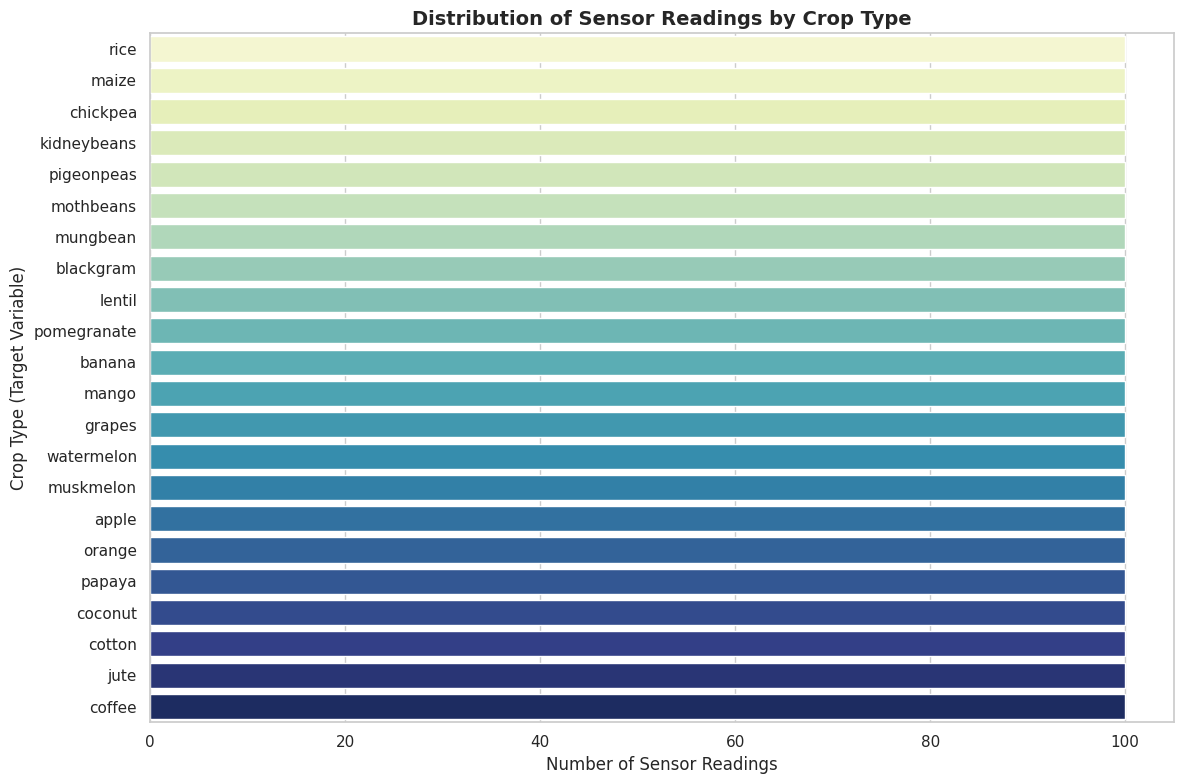

In [3]:
# Set up the canvas size
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart of the crop types
sns.countplot(data=df, y='label', palette='YlGnBu', order=df['label'].value_counts().index)

# Add professional titles and labels
plt.title('Distribution of Sensor Readings by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Number of Sensor Readings', fontsize=12)
plt.ylabel('Crop Type (Target Variable)', fontsize=12)

# Display the chart cleanly
plt.tight_layout()
plt.show()

### 🌡️ Feature Analysis: Environmental Correlation
Before we feed these sensor metrics into an algorithm, we need to understand how the features interact with one another.

* **Business Insight:** The correlation heatmap below highlights the mathematical relationships between our environmental sensors. For example, if two nutrients are highly positively correlated (close to 1.0), it means they typically appear together in the soil. Understanding these natural relationships helps agronomists verify that the sensor data accurately reflects real-world environmental behaviors.

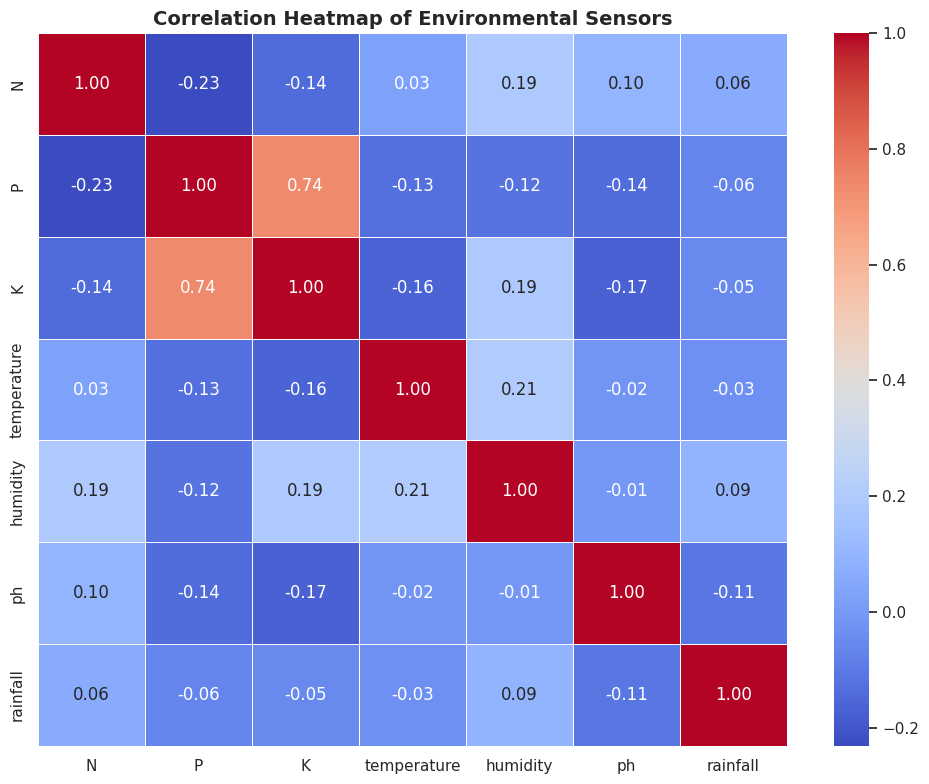

In [4]:
# 1. Isolate only the numerical sensor data (we must drop the text 'label' for this math)
numerical_sensors = df.drop('label', axis=1)

# 2. Set up the canvas
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(numerical_sensors.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 4. Add titles and labels
plt.title('Correlation Heatmap of Environmental Sensors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🌱 Agricultural Insight: Nutrient Signatures
The heatmap revealed a strong mathematical correlation (0.74) between Phosphorus (P) and Potassium (K). But how does a Machine Learning algorithm actually distinguish between 22 different crops?

It looks at their unique "nutrient signatures."

* **Business Insight:** The boxplot below maps out the Nitrogen (N) levels found in the soil for every single crop type in our dataset. Notice the massive variance: crops like Cotton and Coffee demand incredibly high levels of Nitrogen, while legumes (like Lentils and Kidney Beans) require almost none. Because each crop has a distinctly different mathematical "footprint," our classification algorithm will be able to easily identify them.

/tmp/ipykernel_240/607244752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='N', palette='viridis')


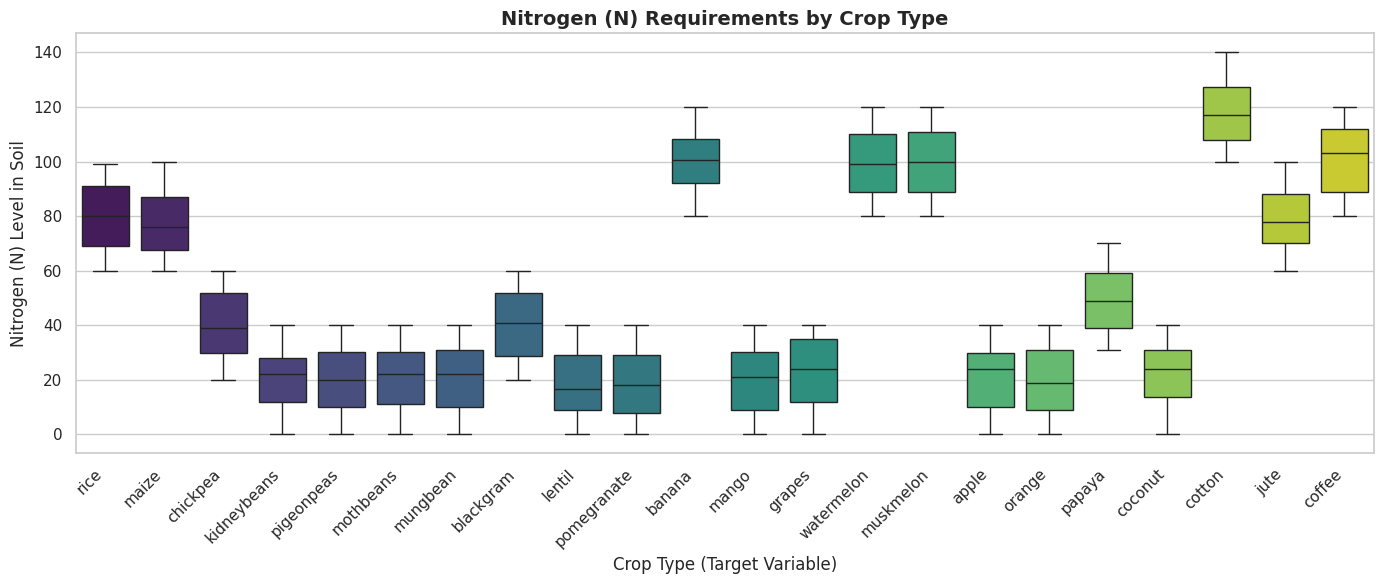

In [5]:
plt.figure(figsize=(14, 6))

# Create a boxplot showing Nitrogen distribution for each crop
sns.boxplot(data=df, x='label', y='N', palette='viridis')

plt.title('Nitrogen (N) Requirements by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type (Target Variable)', fontsize=12)
plt.ylabel('Nitrogen (N) Level in Soil', fontsize=12)

# Rotate the crop names so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 🤖 Predictive Modeling: Multiclass Recommendation Engine
With our environmental signatures mapped, we can now build the recommendation engine.
### Step 1: Data Splitting & Algorithm Training
Unlike human behavioral data, our features (sensor metrics) are already 100% numerical, meaning no mathematical encoding is required. We will separate our target (`label`) from our sensors, split the data into an 80/20 train/test set, and immediately deploy a **Random Forest Classifier** to learn the 22 distinct crop signatures.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Define Features (X) and Target (y)
X = df.drop('label', axis=1)
y = df['label']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Engine: {X_train.shape[0]} sensor readings")
print(f"Testing Engine: {X_test.shape[0]} sensor readings")

# 3. Build and Train the Algorithm
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make recommendations on the hidden testing data
y_pred = rf_model.predict(X_test)

# 5. Evaluate the results
print(f"\n🎯 Recommendation Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

Training Engine: 1760 sensor readings
Testing Engine: 440 sensor readings

🎯 Recommendation Accuracy: 99.32%



### 🌟 Model Evaluation & Feature Importance
Our Random Forest recommendation engine achieved a staggering **99.3% accuracy** on unseen testing data. This exceptionally high performance is characteristic of precise, IoT-derived environmental data compared to unpredictable human behavioral datasets.

To provide actionable insights to agronomists, we extracted the **Feature Importance** from the algorithm. This ranks the environmental sensors based on how much mathematical weight the AI gives them when deciding which crop to recommend.

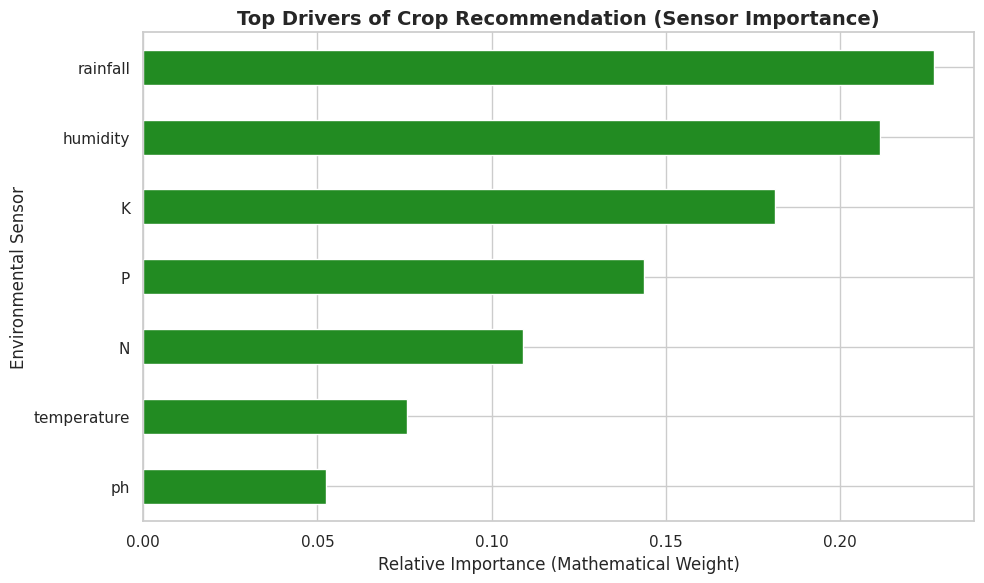

In [7]:
# Extract feature importances from the trained model
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Plot the sensor importance
plt.figure(figsize=(10, 6))
feature_importances.sort_values().plot(kind='barh', color='forestgreen')
plt.title('Top Drivers of Crop Recommendation (Sensor Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Mathematical Weight)')
plt.ylabel('Environmental Sensor')
plt.tight_layout()
plt.show()

### 🏆 Business Conclusion: Maximizing Agricultural Yield
By extracting the feature importance from our Random Forest model, we have isolated the environmental metrics that carry the most mathematical weight in predicting crop viability.

**Key Agronomic Takeaways:**
1. **Water is the Ultimate Driver:** **Rainfall** and **Humidity** are the two most critical sensors. While fertilizers can manually adjust soil nutrients, the natural climate and water availability fundamentally dictate which crop will succeed.
2. **Potassium (K) over Nitrogen (N):** Interestingly, the algorithm prioritizes Potassium and Phosphorus levels over Nitrogen when making its final classification, indicating that the baseline mineral composition of the soil is highly distinct across these 22 crop profiles.

**Final Recommendation:** Farm management should integrate this machine learning model directly into their IoT sensor dashboards. By feeding live rainfall and soil nutrient API data into this 99.3% accurate engine, agronomists can automate crop rotation planning and eliminate human error in yield forecasting.